# Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, 
                           classification_report)

from imblearn.over_sampling import SMOTE

plt.style.use('default')
sns.set_palette("husl")

/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/input/creditcard_clean.csv')

Pré-Processamento

In [3]:
features = df.columns[:-1]  
target = df.columns[-1]

print(f'Features: {features}')
print(f'Target: {target}')

Features: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')
Target: Class


In [4]:
y = df['Class']
X = df.drop('Class', axis=1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
def calculate_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Modelo": model_name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
    }

# XGBoost Normal

In [7]:
xgb_normal = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [8]:
xgb_normal.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [9]:
y_pred_normal = xgb_normal.predict(X_test)
y_proba_normal = xgb_normal.predict_proba(X_test)[:, 1]

In [10]:
y_pred_normal_train = xgb_normal.predict(X_train)
results_normal_train = calculate_metrics(y_train, y_pred_normal_train, "XGBoost Normal")

In [11]:
results_normal = calculate_metrics(y_test, y_pred_normal, "XGBoost Normal")

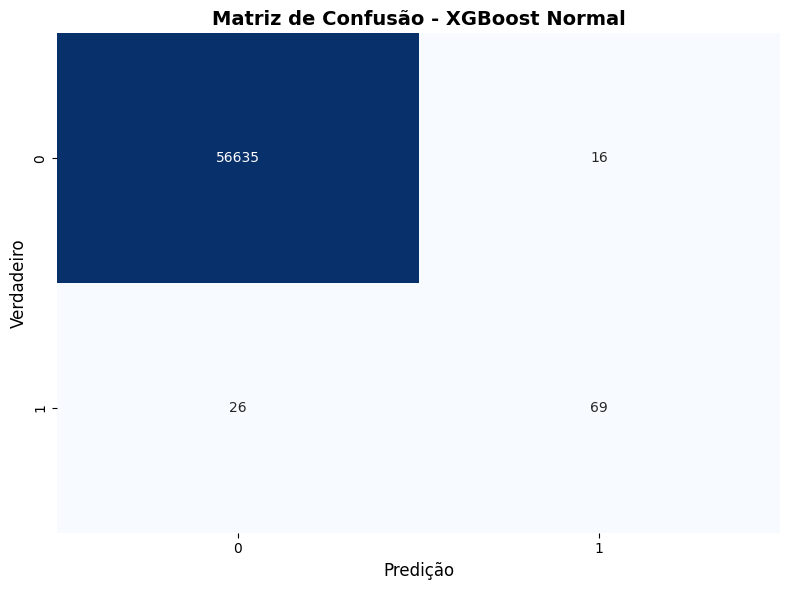

In [12]:
cm_normal = confusion_matrix(y_test, y_pred_normal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - XGBoost Normal', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# XGBoost com Balanceamento

In [13]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Normal/Fraude: {ratio:.2f}")

Normal/Fraude: 599.48


In [14]:
xgb_weighted = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

In [15]:
xgb_weighted.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
y_pred_weighted = xgb_weighted.predict(X_test)
y_proba_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

In [17]:
y_pred_weighted_train = xgb_weighted.predict(X_train)
results_weighted_train = calculate_metrics(y_train, y_pred_weighted_train, "XGBoost Balanceado")

In [18]:
results_weighted = calculate_metrics(y_test, y_pred_weighted, "XGBoost Balanceado")

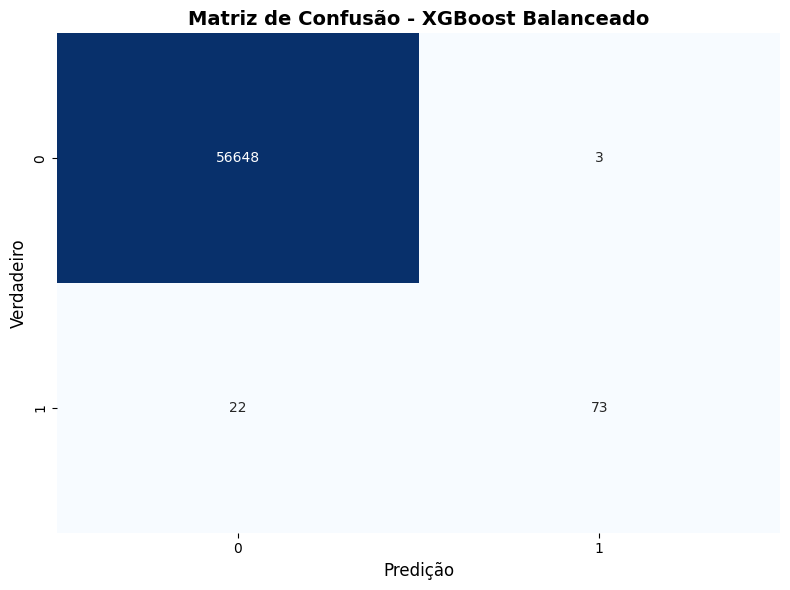

In [19]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - XGBoost Balanceado', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# XGBoost com SMOTE

In [20]:
smote = SMOTE(random_state=42)

In [21]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [22]:
print(f"Antes (y_train): {y_train.value_counts().to_dict()}")
print(f"Depois (y_train): {y_train_smote.value_counts().to_dict()}")

Antes (y_train): {0: 226602, 1: 378}
Depois (y_train): {0: 226602, 1: 226602}


In [23]:
xgb_smote = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [24]:
xgb_smote.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
y_pred_smote = xgb_smote.predict(X_test)
y_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

In [26]:
y_pred_smote_train = xgb_smote.predict(X_train)

In [27]:
results_smote = calculate_metrics(y_test, y_pred_smote, "XGBoost SMOTE")

In [28]:
results_smote_train = calculate_metrics(y_train, y_pred_smote_train, "XGBoost SMOTE")

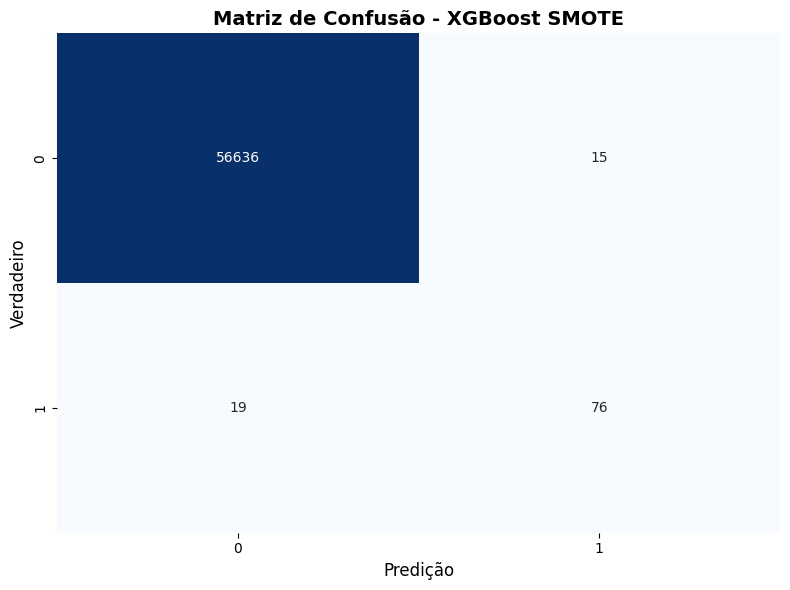

In [29]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - XGBoost SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# XGBoost com Hiperparâmetros

In [30]:
xgb_optimized = xgb.XGBClassifier(
    # Boosting
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    
    # Regularização
    reg_alpha=0.1,
    reg_lambda=1.0,
    
    # Amostragem
    subsample=0.8,
    colsample_bytree=0.8,
    
    # Balanceamento
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

In [31]:
xgb_optimized.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
y_pred_optimized = xgb_optimized.predict(X_test)
y_proba_optimized = xgb_optimized.predict_proba(X_test)[:, 1]

In [33]:
y_pred_optimized_train = xgb_optimized.predict(X_train)
results_optimized_train = calculate_metrics(y_train, y_pred_optimized_train, "XGBoost Otimizado")

In [34]:
results_optimized = calculate_metrics(y_test, y_pred_optimized, "XGBoost Otimizado")

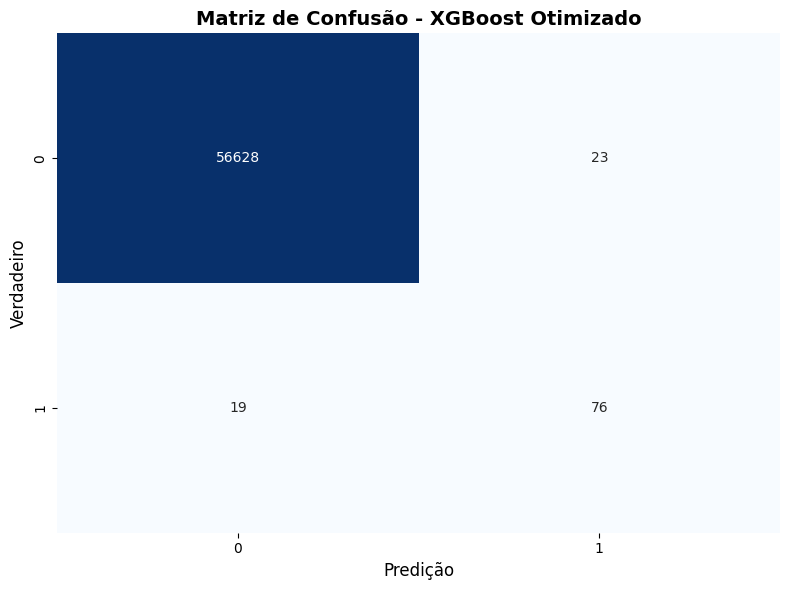

In [35]:
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - XGBoost Otimizado', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# XGBoost Optuna

In [ ]:

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "eta": trial.suggest_float("eta", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 80, 250),
        "tree_method": "hist",
        "n_jobs": -1,
        "eval_metric": "logloss",
        "scale_pos_weight": ratio
    }
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=2, n_jobs=-1).mean()
    return score

In [55]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

[I 2025-11-05 11:43:06,035] A new study created in memory with name: no-name-d5242c16-3cb5-4eff-8ce6-e4a3a56cb04d


In [57]:
study.optimize(objective, n_trials=100, n_jobs=-1)

/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:43:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:43:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:43:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/x

In [58]:
print("Melhores hiperparâmetros:")
print(study.best_params)

Melhores hiperparâmetros:
{'max_depth': 9, 'eta': 0.29645588828921116, 'subsample': 0.7047878856367907, 'colsample_bytree': 0.6028671207792522, 'n_estimators': 187}


In [59]:
best_params = study.best_params

In [ ]:
xgb_optuna = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=ratio,
    tree_method="hist",
    n_jobs=-1,
    eval_metric="logloss"
)

In [61]:
xgb_optuna.fit(X_train, y_train)

/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:48:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6028671207792522
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [62]:
y_pred_optuna = xgb_optuna.predict(X_test)
y_proba_optuna = xgb_optuna.predict_proba(X_test)[:, 1]


y_pred_optuna_train = xgb_optuna.predict(X_train)

In [63]:
results_optuna_train = calculate_metrics(y_train, y_pred_optuna_train, "XGBoost Optuna")
results_optuna = calculate_metrics(y_test, y_pred_optuna, "XGBoost Optuna")

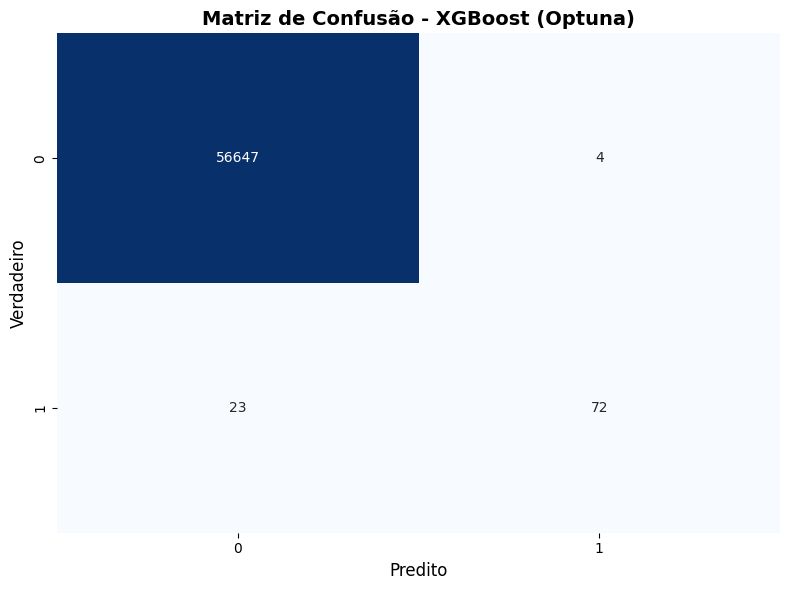

In [64]:
cm_optuna = confusion_matrix(y_test, y_pred_optuna)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optuna, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - XGBoost (Optuna)', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predito', fontsize=12)
plt.tight_layout()
plt.show()

# Comparação de Resultados

In [65]:
all_results = pd.DataFrame([
    results_normal,
    results_weighted, 
    results_smote,
    results_optimized,
    results_optuna
])

In [66]:
all_results_train = pd.DataFrame([
    results_normal_train,
    results_weighted_train, 
    results_smote_train,
    results_optimized_train,
    results_optuna_train
])

In [67]:
all_results

,Modelo,Precision,Recall,F1
0,XGBoost Normal,0.811765,0.726316,0.766667
1,XGBoost Balanceado,0.960526,0.768421,0.853801
2,XGBoost SMOTE,0.835165,0.800000,0.817204
3,XGBoost Otimizado,0.767677,0.800000,0.783505
4,XGBoost Optuna,0.947368,0.757895,0.842105


In [68]:
all_results_train

,Modelo,Precision,Recall,F1
0,XGBoost Normal,0.991957,0.978836,0.985353
1,XGBoost Balanceado,1.000000,1.000000,1.000000
2,XGBoost SMOTE,1.000000,1.000000,1.000000
3,XGBoost Otimizado,0.853273,1.000000,0.920828
4,XGBoost Optuna,1.000000,1.000000,1.000000


# Hiperparâmetros

eta (learning_rate)
* Tamanho do passo para encontrar o mínimo no gradiente
* Mais baixo -> mais lento e mais estável

n_estimators
* Número de árcores criadas
* Mais árvores -> mais poder de aprendizado e mais risco de overfitting

max_depth
* Profundidade máxima de cada árvore
* Mesma coisa de n_estimators

min_child_weight
* Peso mínimo total dos exemplos que um nó filho precisa para ser criado
* Evita que a árvore seja construída com base em poucos exemplos -> reduz overfitting

subsample
* Porcentagem das amostras usadas em cada árvore
* Menor valor -> mais aleatoriedade, menos overfitting

colsample_bytree
* Porcentagem de features usadas em cada árvore

lambda e alpha
* Controlam a penalização sobre o tamanho dos pesos das folhas
* Evita que o modelo fique complexo demais

gamma
* Ganho mínimo necessário para dividir um nó
* Valor maior -> menos divisões

lambda (L2)
* Penaliza pesos grandes nas folhas (valores muito extremos de predição)
* ~ Ridge
* Penalização suave, que puxa os valores das folhas para mais perto de zero
* Modelo fica mais estável e menos sensível a ruído nos dados

alpha (L1)
* Zera pesos muito pequenos
* ~ Lasso
* Gera modelos mais simples, com menos regras e divisões

gamma
* Cada vez que o modelo quer criar um novo nó, precisa gerar um ganho de desempenho maior que gamma
* Se o ganho for pequeno, a divisão não é feita
* Reduz o número de nós